# 03 — Baseline XGBoost Classifier
**Goal:** Visualize the classifier results — confusion matrix, SHAP feature importance,
and per-driver confidence scores.

The model was already trained and evaluated in `baseline.py`.
This notebook loads the saved model and makes the results interpretable.

In [14]:
import os
import yaml
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score
import xgboost as xgb

with open('../config.yaml') as f:
    config = yaml.safe_load(f)

RACE_TAG     = f"{config['session']['year']}_{config['session']['race'].lower()}"
FEATURES_DIR = os.path.join('..', config['data']['features_dir'])
MODELS_DIR   = os.path.join('..', 'outputs', 'models')
FIGS_DIR     = os.path.join('..', 'outputs', 'figures')
DRIVERS      = config['drivers']
COLORS       = {'VER': '#1E3A8A', 'HAM': '#7C3AED', 'ALO': '#B91C1C'}
SEED         = config['model']['random_seed']

FEATURE_COLS = [
    'brake_duration_ratio', 'throttle_smoothness', 'full_throttle_ratio',
    'coasting_ratio', 'gear_change_freq', 'speed_at_throttle_lift',
    'mean_corner_speed', 'speed_variance', 'throttle_brake_overlap',
]

os.makedirs(FIGS_DIR, exist_ok=True)
print('Setup complete')

Setup complete


## 1. Load data + model

In [15]:
df    = pd.read_csv(os.path.join(FEATURES_DIR, f'{RACE_TAG}_features.csv'))
model = joblib.load(os.path.join(MODELS_DIR, f'{RACE_TAG}_xgb_baseline.pkl'))
le    = joblib.load(os.path.join(MODELS_DIR, f'{RACE_TAG}_label_encoder.pkl'))

X = df[FEATURE_COLS].values
y = le.transform(df['Driver'].values)

print(f'Data: {X.shape}  |  Classes: {list(le.classes_)}')
print(f'Model: {model.__class__.__name__}')

Data: (159, 9)  |  Classes: ['ALO', 'HAM', 'VER']
Model: XGBClassifier


## 2. Re-run CV to get OOF predictions for honest evaluation

In [16]:
cv_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='mlogloss', random_state=SEED, n_jobs=-1
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

y_pred = cross_val_predict(cv_model, X, y, cv=cv, method='predict')
y_prob = cross_val_predict(cv_model, X, y, cv=cv, method='predict_proba')

acc = accuracy_score(y, y_pred)
random_baseline = 1 / len(le.classes_)

print(f'OOF Accuracy:      {acc*100:.1f}%')
print(f'Random baseline:   {random_baseline*100:.1f}%')
print(f'Lift over random:  +{(acc - random_baseline)*100:.1f} pp')

OOF Accuracy:      93.7%
Random baseline:   33.3%
Lift over random:  +60.4 pp


## 3. Confusion matrix

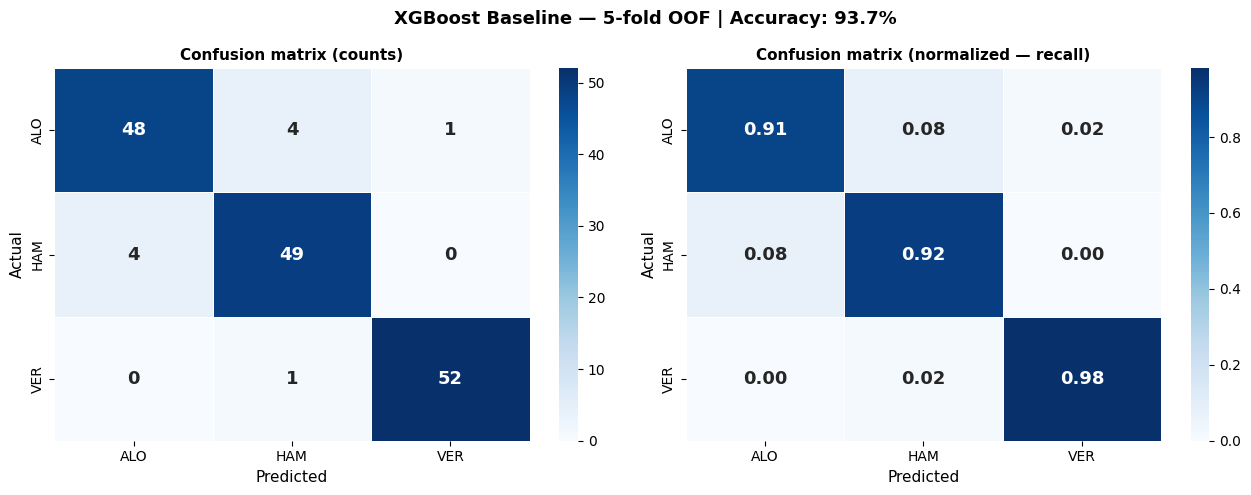

In [17]:
cm = confusion_matrix(y, y_pred)
# Normalize by row (actual) so values = recall per class
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, data, title, fmt in zip(
    axes,
    [cm, cm_norm],
    ['Confusion matrix (counts)', 'Confusion matrix (normalized — recall)'],
    ['d', '.2f']
):
    sns.heatmap(
        data, annot=True, fmt=fmt, cmap='Blues',
        xticklabels=le.classes_, yticklabels=le.classes_,
        ax=ax, linewidths=0.5, linecolor='white',
        annot_kws={'size': 13, 'weight': 'bold'}
    )
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_title(title, fontsize=11, fontweight='bold')

fig.suptitle(f'XGBoost Baseline — 5-fold OOF | Accuracy: {acc*100:.1f}%', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '03_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. SHAP — which features drive each prediction?

SHAP values tell you: for this specific prediction, how much did each feature
push the model toward or away from each class.
This is the interpretability story for your resume.

SHAP values shape: (159, 9, 3)
Classes: ['ALO', 'HAM', 'VER']


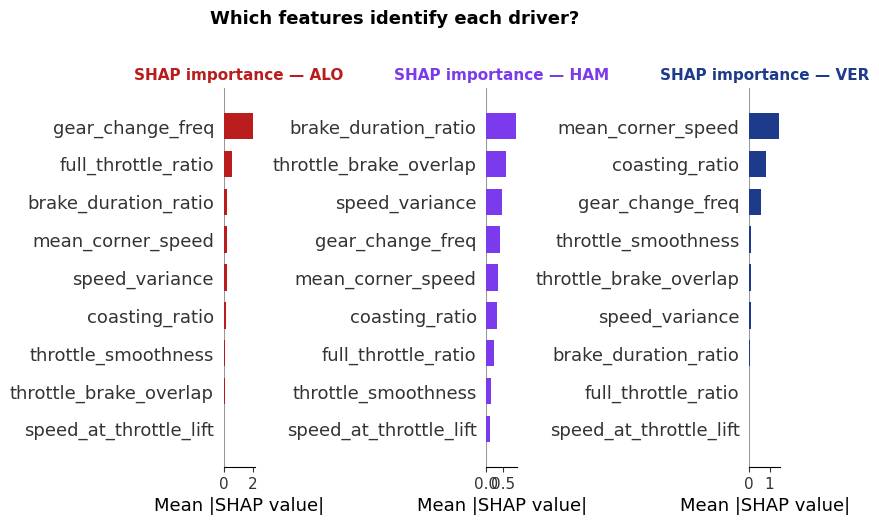

In [18]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

# SHAP returns (n_samples, n_features, n_classes)
# Slice last axis per class: shap_values[:, :, i]
print(f'SHAP values shape: {np.array(shap_values).shape}')
print(f'Classes: {list(le.classes_)}')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (driver, ax) in enumerate(zip(le.classes_, axes)):
    plt.sca(ax)
    shap.summary_plot(
        shap_values[:, :, i],      # <-- fixed: slice on last axis
        X,
        feature_names=FEATURE_COLS,
        plot_type='bar',
        show=False,
        color=COLORS[driver],
    )
    ax.set_title(f'SHAP importance — {driver}', fontsize=11, 
                 fontweight='bold', color=COLORS[driver])
    ax.set_xlabel('Mean |SHAP value|')

plt.suptitle('Which features identify each driver?', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '03_shap_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

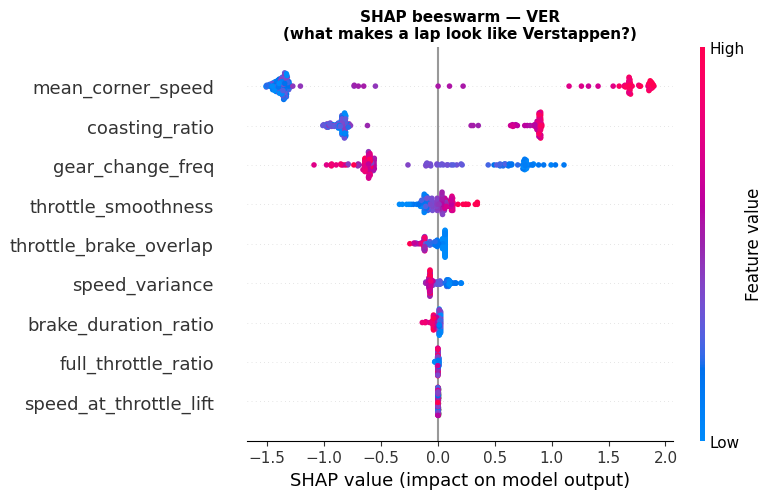

In [19]:
# Summary plot: one plot per driver class
# Shows which features push predictions TOWARD this driver

ver_idx = list(le.classes_).index('VER')

plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_values[:, :, ver_idx],    # <-- fixed: slice on last axis
    X,
    feature_names=FEATURE_COLS,
    show=False,
)
plt.title('SHAP beeswarm — VER\n(what makes a lap look like Verstappen?)',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '03_shap_beeswarm_ver.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.show()

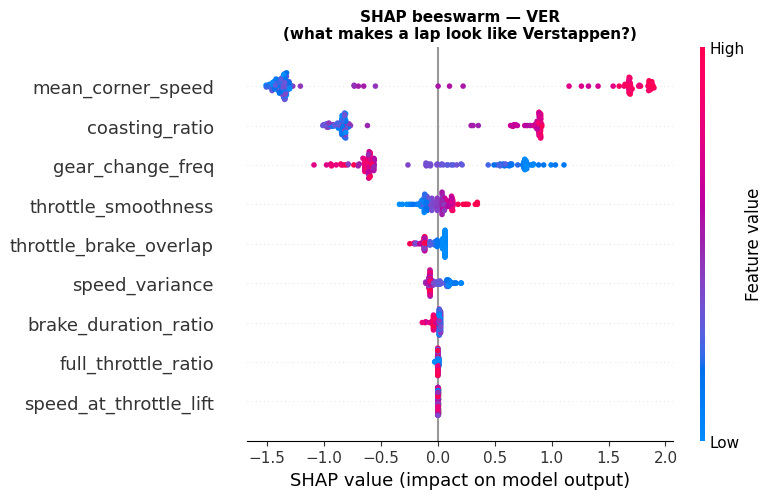

In [20]:
# Beeswarm plot for VER — shows direction of each feature's effect
# Red dot = high feature value, Blue dot = low feature value
# Right of center = pushes toward VER, Left = pushes away

ver_idx = list(le.classes_).index('VER')

plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_values[:, :, ver_idx],    
    X,
    feature_names=FEATURE_COLS,
    show=False,
)
plt.title('SHAP beeswarm — VER\n(what makes a lap look like Verstappen?)',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '03_shap_beeswarm_ver.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Per-driver prediction confidence

For each lap, the model gives a probability for each driver.
How confident is it when it gets things right vs wrong?

In [21]:
df_results = df[['Driver', 'LapNumber', 'LapTime_s']].copy()
df_results['predicted']    = le.inverse_transform(y_pred)
df_results['correct']      = df_results['Driver'] == df_results['predicted']

for i, cls in enumerate(le.classes_):
    df_results[f'prob_{cls}'] = y_prob[:, i]

df_results['confidence'] = y_prob.max(axis=1)

print('Overall accuracy:', df_results['correct'].mean().round(4))
print('\nPer-driver accuracy:')
print(df_results.groupby('Driver')['correct'].mean().round(4))
print('\nMean confidence when correct vs wrong:')
print(df_results.groupby('correct')['confidence'].mean().round(4))

Overall accuracy: 0.9371

Per-driver accuracy:
Driver
ALO    0.9057
HAM    0.9245
VER    0.9811
Name: correct, dtype: float64

Mean confidence when correct vs wrong:
correct
False    0.8308
True     0.9516
Name: confidence, dtype: float32


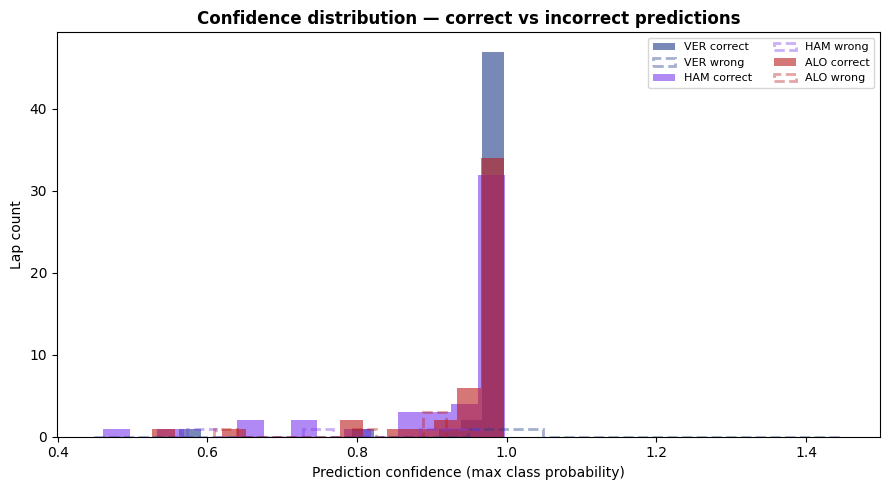

In [22]:
# Confidence distribution per driver
fig, ax = plt.subplots(figsize=(9, 5))

for driver in DRIVERS:
    sub = df_results[df_results['Driver'] == driver]
    correct   = sub[sub['correct']]['confidence']
    incorrect = sub[~sub['correct']]['confidence']

    ax.hist(correct,   bins=15, alpha=0.6, color=COLORS[driver],
            label=f'{driver} correct', histtype='stepfilled')
    ax.hist(incorrect, bins=10, alpha=0.4, color=COLORS[driver],
            label=f'{driver} wrong', histtype='step', linewidth=2, linestyle='--')

ax.set_xlabel('Prediction confidence (max class probability)')
ax.set_ylabel('Lap count')
ax.set_title('Confidence distribution — correct vs incorrect predictions', fontweight='bold')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '03_confidence_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# Which laps did the model get wrong? Print them.
wrong = df_results[~df_results['correct']].sort_values('confidence', ascending=False)
print(f'Misclassified laps: {len(wrong)} / {len(df_results)}')
print()
print(wrong[['Driver', 'LapNumber', 'predicted', 'confidence', 'LapTime_s']].to_string(index=False))

Misclassified laps: 10 / 159

Driver  LapNumber predicted  confidence  LapTime_s
   HAM       10.0       ALO    0.962560    100.289
   VER       36.0       HAM    0.948850    100.964
   ALO       11.0       HAM    0.918354    101.147
   ALO       16.0       HAM    0.914427     97.542
   ALO        8.0       HAM    0.912064     99.959
   HAM        1.0       ALO    0.901998    102.288
   ALO        4.0       VER    0.823641     99.548
   HAM       48.0       ALO    0.744753     97.844
   ALO       12.0       HAM    0.609297    100.934
   HAM       37.0       ALO    0.572148     97.388


## 6. Feature importance (XGBoost built-in)

Quick comparison: XGBoost's built-in importance vs SHAP.
SHAP is more reliable — built-in importance can be biased toward
high-cardinality features.

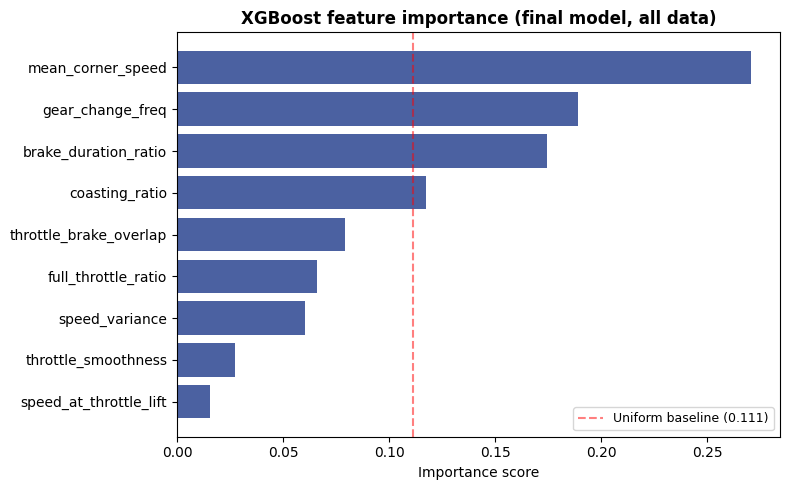

In [24]:
fi_df = pd.read_csv(os.path.join(FEATURES_DIR, f'{RACE_TAG}_feature_importance.csv'))

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(
    fi_df['feature'][::-1],
    fi_df['importance'][::-1],
    color='#1E3A8A', alpha=0.8
)
ax.set_xlabel('Importance score')
ax.set_title('XGBoost feature importance (final model, all data)', fontweight='bold')
ax.axvline(x=1/len(FEATURE_COLS), color='red', linestyle='--', alpha=0.5,
           label=f'Uniform baseline ({1/len(FEATURE_COLS):.3f})')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '03_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Milestone 3 complete ✓

You now have:
- A trained XGBoost baseline with honest 5-fold OOF accuracy
- Confusion matrix showing which drivers get confused with each other
- SHAP values explaining exactly which features identify each driver
- Confidence analysis showing how certain the model is per prediction

**Next:** `04_embedding_visualization.ipynb` — 1D-CNN encoder, 32-dim driver embeddings, UMAP plot.